# Визуализация атакованных признаков

Этот ноутбук сравнивает входные признаки и конечные признаки после атаки, а также строит распределение `importance` из `graph.json`.

Ожидаемые файлы:
- `data/data_for_attack.csv`
- `C#/NCT_attack/results/adversarial_samples.json`
- `model/graph.json`


In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
root = Path('../').resolve()
root
# Подстройте пути при необходимости
input_csv = root / 'data' / 'data_for_attack.csv'
adv_json = root / 'C#' / 'NCT_attack' / 'results' / 'adversarial_samples.json'
graph_json = root / 'model' / 'graph.json'

input_csv, adv_json, graph_json

(WindowsPath('C:/Users/sukharev/Desktop/maga/diplom/NCT-research/PIPELINE/data/data_for_attack.csv'),
 WindowsPath('C:/Users/sukharev/Desktop/maga/diplom/NCT-research/PIPELINE/C#/NCT_attack/results/adversarial_samples.json'),
 WindowsPath('C:/Users/sukharev/Desktop/maga/diplom/NCT-research/PIPELINE/model/graph.json'))

In [9]:
# Загружаем входные данные
# Формат: id, class, split, f0..f511
input_df = pd.read_csv(input_csv)
input_df.head()

,id,class,split,f0,f1,f2,f3,f4,f5,f6,...,f502,f503,f504,f505,f506,f507,f508,f509,f510,f511
0,599,42,test,-19.762665,-1.571682,-4.758049,8.974822,14.018645,10.305649,-1.087421,...,-4.150668,-2.819620,-5.103311,-10.243926,-2.122184,-5.978384,-7.924068,-2.337071,-5.692710,5.604058
1,614,43,test,-1.920413,-2.433629,-1.951138,9.754785,-0.014691,-7.108594,1.586786,...,5.677354,-1.494369,-7.376622,-2.806334,11.872024,-1.841996,3.251793,-5.906789,-4.964036,-7.979676
2,810,57,test,0.174929,5.309589,-7.760623,-8.616673,-3.703434,1.260058,-6.222724,...,-2.249753,-4.604228,-8.120267,7.189878,-7.482601,11.130211,2.250556,-0.732183,-3.312277,9.114481
3,1217,86,test,-7.212712,-3.382051,1.863428,3.553390,1.853421,0.449263,-7.824228,...,2.680042,-8.158259,-5.454784,-0.430853,-10.354815,-4.609235,17.526081,0.118829,-4.436415,24.923298
4,1340,95,test,-3.167191,7.791289,1.199360,0.533245,4.754425,-0.725896,4.393354,...,-2.035851,-6.226272,-8.274585,3.731900,1.463506,-0.603477,0.274665,-1.941170,-3.176950,22.217213


In [17]:
# Загружаем результаты атаки
with open(adv_json, 'r', encoding='utf-8') as f:
    adv_data = json.load(f)

adv_samples = pd.DataFrame(adv_data['samples'])
adv_samples.head()

,id,true_class,features
0,599,42,"[-17.190164794920037, -1.5716819763183594, -4...."
1,614,43,"[1.1665874595641679, -2.433629274368286, -1.95..."
2,810,57,"[2.7649285012482823, 5.30958890914917, -7.7606..."
3,1217,86,"[-4.237711811065058, -3.3820509910583496, 1.86..."
4,1340,95,"[-0.6506905517579078, 7.791289329528809, 1.199..."


In [11]:
# Подготовка для сравнения
feature_cols = [c for c in input_df.columns if c.startswith('f')]

# Преобразуем список признаков в массивы
adv_samples['features'] = adv_samples['features'].apply(np.array)

# Маппинг по id
input_by_id = input_df.set_index('id')
adv_by_id = adv_samples.set_index('id')

# Проверка пересечения
common_ids = input_by_id.index.intersection(adv_by_id.index)
len(common_ids)

5

СТАТИСТИКА ПО IMPORTANCE:
Всего признаков: 320
Признаков с нулевым важность: 221
Признаков с ненулевым важность: 99
Порог (среднее ненулевых важность): 0.2586
Признаков с важность > 0.2586: 31



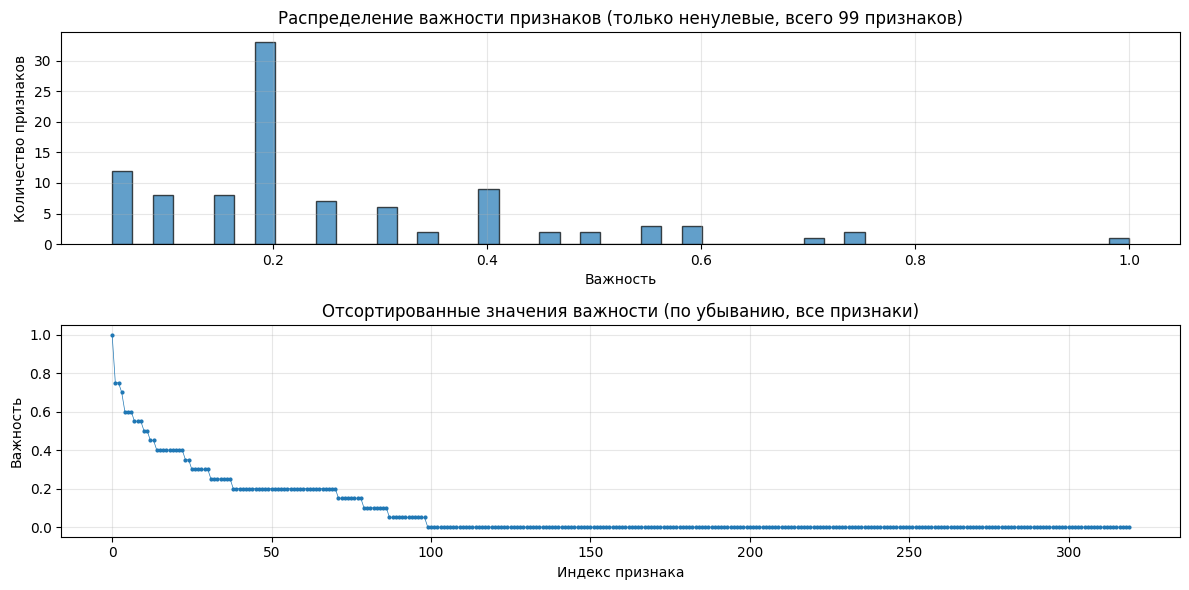


Статистика по значениям важность:
Минимальное важность среди ненулевых: 0.0500
Среднее важность (общее): 0.0800
Среднее важность (для ненулевых): 0.2000


In [12]:
# Загружаем граф корреляций и строим распределение importance
with open(graph_json, 'r', encoding='utf-8') as f:
    graph_data = json.load(f)

# Извлекаем importance для всех признаков
features_data = graph_data.get('features', {})
importance_values = []

for feature_id, feature_info in features_data.items():
    importance = feature_info.get('importance', 0.0)
    importance_values.append(importance)

importance_values = np.array(importance_values)

# Фильтруем только ненулевые значения
nonzero_importance_values = importance_values[importance_values > 0.0]

# Вычисляем порог как среднее ненулевых importance
threshold = np.mean(nonzero_importance_values)

# Статистика перед графиком
zero_importance = np.sum(importance_values == 0.0)
nonzero_importance = np.sum(importance_values > 0.0)
above_threshold = np.sum(importance_values > threshold)

print('СТАТИСТИКА ПО IMPORTANCE:')
print(f'Всего признаков: {len(importance_values)}')
print(f'Признаков с нулевым важность: {zero_importance}')
print(f'Признаков с ненулевым важность: {nonzero_importance}')
print(f'Порог (среднее ненулевых важность): {threshold:.4f}')
print(f'Признаков с важность > {threshold:.4f}: {above_threshold}')
print()

# Построение графика распределения importance (только ненулевые)
plt.figure(figsize=(12, 6))

# Гистограмма для ненулевых значений
plt.subplot(2, 1, 1)
plt.hist(nonzero_importance_values, bins=50, edgecolor='black', alpha=0.7)
plt.title(f'Распределение важности признаков (только ненулевые, всего {nonzero_importance} признаков)')
plt.xlabel('Важность')
plt.ylabel('Количество признаков')
plt.grid(True, alpha=0.3)

# График отсортированных значений importance (все)
plt.subplot(2, 1, 2)
sorted_nonzero_importance = np.sort(importance_values)[::-1]
plt.plot(sorted_nonzero_importance, marker='o', markersize=2, linewidth=0.5)
plt.title(f'Отсортированные значения важности (по убыванию, все признаки)')
plt.xlabel('Индекс признака')
plt.ylabel('Важность')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика по ненулевым значениям
print(f'\nСтатистика по значениям важность:')
print(f'Минимальное важность среди ненулевых: {np.min(nonzero_importance_values):.4f}')
print(f'Среднее важность (общее): {np.mean(importance_values):.4f}')
print(f'Среднее важность (для ненулевых): {np.median(nonzero_importance_values):.4f}')

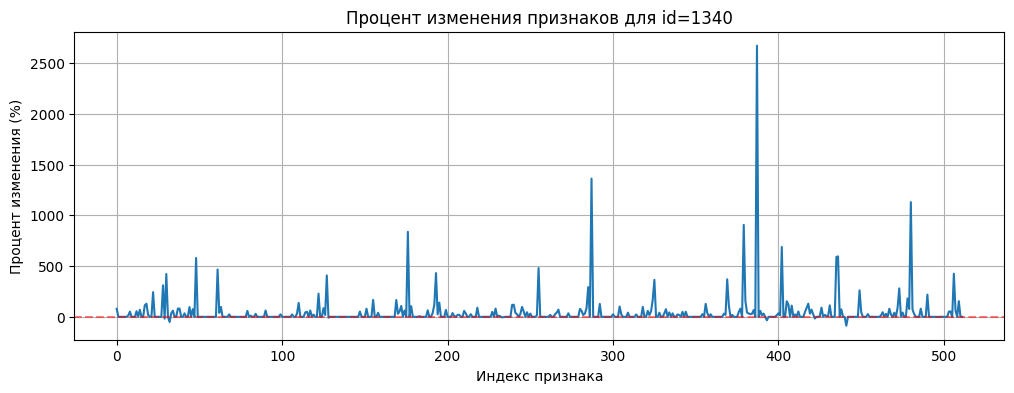

СТАТИСТИКА ПО ИЗМЕНЕНИЮ ПРИЗНАКОВ:
Всего признаков: 512
Изменено: 196
Нетронуто: 316
Процент признаков с изменением: 38.28%

Абсолютные изменения:
  Границы значений: [-23.575975, 26.559877]
  Средняя величина изменения: 0.961007
  Максимальная величина изменения: 8.298000

Процентные изменения:
  Средний процент изменения (по модулю): 46.82%
  Средний процент изменения (без топ-10): 28.14%
  Максимальный процент изменения: 2672.24%
  Признаков с изменением > 10%: 183
  Признаков с изменением > 50%: 101
  Признаков с изменением > 100%: 48


In [14]:
# Визуализация изменения признаков для выбранного образца
sample_id = int(common_ids[4])  # поменяйте при необходимости

x_orig = input_by_id.loc[sample_id, feature_cols].to_numpy(dtype=float)
x_adv = adv_by_id.loc[sample_id, 'features']

# Процент изменения (избегаем деления на ноль)
delta = x_adv - x_orig
percent_change = np.where(np.abs(x_orig) > 1e-6, 
                          (delta / np.abs(x_orig)) * 100, 
                          np.where(np.abs(delta) > 1e-6, np.sign(delta) * 1000, 0))

plt.figure(figsize=(12, 4))
plt.plot(percent_change)
plt.title(f'Процент изменения признаков для id={sample_id}')
plt.xlabel('Индекс признака')
plt.ylabel('Процент изменения (%)')
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

# Статистика по изменению признаков
abs_percent_change = np.abs(percent_change)
abs_delta = np.abs(delta)

# Подсчет признаков с изменениями
changed_features = np.sum(abs_delta > 1e-6)  # признаков с изменением
unchanged_features = np.sum(abs_delta <= 1e-6)  # признаков без изменения

# Статистика по процентам (исключаем случаи с очень большими процентами из-за малых исходных значений)
valid_percent_mask = np.abs(x_orig) > 1e-6
valid_percent_change = percent_change[valid_percent_mask]
valid_abs_percent_change = abs_percent_change[valid_percent_mask]

print('=' * 70)
print('СТАТИСТИКА ПО ИЗМЕНЕНИЮ ПРИЗНАКОВ:')
print('=' * 70)
print(f'Всего признаков: {len(feature_cols)}')
print(f'Изменено: {changed_features}')
print(f'Нетронуто: {unchanged_features}')
print(f'Процент признаков с изменением: {changed_features/len(feature_cols)*100:.2f}%')
print()
print('Абсолютные изменения:')
print(f'  Границы значений: [{np.min(x_orig):.6f}, {np.max(x_orig):.6f}]')
print(f'  Средняя величина изменения: {np.mean(abs_delta):.6f}')
print(f'  Максимальная величина изменения: {np.max(abs_delta):.6f}')
print()
print('Процентные изменения:')
if len(valid_percent_change) > 0:
    print(f'  Средний процент изменения (по модулю): {np.mean(valid_abs_percent_change):.2f}%')
    # print(f'  Средний процент изменения (с учетом знака): {np.mean(valid_percent_change):+.2f}%')
    
    # Средний процент изменения без топ-10
    sorted_abs_percent = np.sort(valid_abs_percent_change)[::-1]
    if len(sorted_abs_percent) > 10:
        mean_without_top10 = np.mean(sorted_abs_percent[10:])
        print(f'  Средний процент изменения (без топ-10): {mean_without_top10:.2f}%')
    
    print(f'  Максимальный процент изменения: {np.max(valid_abs_percent_change):.2f}%')
    print(f'  Признаков с изменением > 10%: {np.sum(valid_abs_percent_change > 10)}')
    print(f'  Признаков с изменением > 50%: {np.sum(valid_abs_percent_change > 50)}')
    print(f'  Признаков с изменением > 100%: {np.sum(valid_abs_percent_change > 100)}')
else:
    print('  Недостаточно данных для расчета процентных изменений')
print('=' * 70)

In [15]:
# Топ изменённых признаков (по проценту изменения)
k = 20
abs_percent_change = np.abs(percent_change)
idx_sorted = np.argsort(abs_percent_change)[::-1]

print('Топ изменённых признаков (по проценту изменения):')
for i in idx_sorted[:k]:
    print(f'f{i}: {percent_change[i]:+.2f}%, orig={x_orig[i]:.6f}, adv={x_adv[i]:.6f}')

Топ изменённых признаков (по проценту изменения):
f387: +2672.24%, orig=-0.086257, adv=2.218743
f287: +1362.60%, orig=-0.169162, adv=2.135838
f480: +1130.36%, orig=-0.203475, adv=2.096525
f379: +906.20%, orig=0.253808, adv=2.553808
f176: +837.81%, orig=-0.261366, adv=1.928384
f402: +689.12%, orig=-0.334487, adv=1.970513
f436: +595.52%, orig=0.387054, adv=2.692054
f435: +589.95%, orig=-0.583523, adv=2.858977
f48: +580.30%, orig=-0.714974, adv=3.434026
f255: +481.18%, orig=-0.479028, adv=1.825972
f61: +467.21%, orig=-0.937373, adv=3.442127
f193: +431.29%, orig=0.534441, adv=2.839441
f506: +425.25%, orig=1.463506, adv=7.687006
f30: +422.05%, orig=-1.817304, adv=5.852696
f127: +408.47%, orig=0.479652, adv=2.438902
f369: +369.93%, orig=0.623097, adv=2.928097
f325: +364.75%, orig=1.895807, adv=8.810807
f28: +310.79%, orig=-2.669930, adv=5.628070
f285: +293.23%, orig=0.786085, adv=3.091085
f473: +280.56%, orig=0.821575, adv=3.126575


In [ ]:
# Сохранение графиков для LaTeX документа
output_dir = root / 'results' / 'figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Сохраняем график importance (из ячейки 7)
# Нужно пересоздать график и сохранить
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.hist(nonzero_importance_values, bins=50, edgecolor='black', alpha=0.7)
plt.title(f'Распределение importance признаков (только ненулевые, всего {nonzero_importance} признаков)')
plt.xlabel('Importance')
plt.ylabel('Количество признаков')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
sorted_nonzero_importance = np.sort(importance_values)[::-1]
plt.plot(sorted_nonzero_importance, marker='o', markersize=2, linewidth=0.5)
plt.title(f'Отсортированные значения importance (по убыванию, все признаки)')
plt.xlabel('Индекс признака')
plt.ylabel('Importance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'importance_distribution.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'importance_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print(f'График importance сохранен: {output_dir / "importance_distribution.pdf"}')

# Сохраняем график процента изменения (из ячейки 8)
plt.figure(figsize=(12, 4))
plt.plot(percent_change)
plt.title(f'Процент изменения признаков для id={sample_id}')
plt.xlabel('Индекс признака')
plt.ylabel('Процент изменения (%)')
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.savefig(output_dir / 'percent_change.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'percent_change.png', dpi=300, bbox_inches='tight')
plt.close()
print(f'График процента изменения сохранен: {output_dir / "percent_change.pdf"}')

print(f'\nВсе графики сохранены в: {output_dir}')

In [ ]:
# Генерация LaTeX отчета
import sys
sys.path.append(str(root / 'python' / 'nct_attack'))

from generate_latex_report import generate_latex_report

latex_path = generate_latex_report(root)
print(f'\n✓ LaTeX отчет готов: {latex_path}')
print(f'\nДля компиляции в PDF выполните в терминале:')
print(f'  cd {root / "results"}')
print(f'  pdflatex attack_results.tex')

## Интерпретируемые метрики: относительное изменение + “дистанция до класса”

Эта секция помогает ответить на вопрос: *атака что-то меняет, но насколько это заметно и насколько далеко ушёл пример от “своего” класса (в признаковом/латентном смысле)?*

- **Относительная разница в пикселях**: нормируем MSE и L2 разности `x_adv - x_orig` на масштаб `x_orig`.
- **Дистанция до класса**: считаем расстояние от `x_adv` до центроида признаков класса в том же пространстве `f0..f511` (то есть в латентном/feature-пространстве, где работает атака). Также считаем `rank` класса истинного `class`.


In [ ]:

# -----------------------------
# 2) Собираем pairs orig/adv
# -----------------------------
# Используем уже загруженные input_df / adv_data / feature_cols из ранних ячеек ноутбука.
# Если вы запускаете эту секцию с нуля, убедитесь, что root/input_df/feature_cols/adv_samples определены.

# Переопределяем, чтобы не зависеть от порядка выполнения.
with open(adv_json, 'r', encoding='utf-8') as f:
    adv_data = json.load(f)
adv_samples = pd.DataFrame(adv_data['samples'])
adv_samples['features'] = adv_samples['features'].apply(np.array)

feature_cols = [c for c in input_df.columns if c.startswith('f')]

input_by_id = input_df.set_index('id')
adv_by_id = adv_samples.set_index('id')
common_ids = input_by_id.index.intersection(adv_by_id.index).tolist()
common_ids.sort()

rows = []

# --- decode всех orig и adv батчами (чтобы не декодировать дважды по одному) ---
z_orig = np.stack([input_by_id.loc[i, feature_cols].to_numpy(dtype=float) for i in common_ids], axis=0)
z_adv = np.stack([adv_by_id.loc[i, 'features'] for i in common_ids], axis=0)

with torch.no_grad():
    t_z_orig = torch.tensor(z_orig, dtype=torch.float32, device=device)
    t_z_adv = torch.tensor(z_adv, dtype=torch.float32, device=device)

    img_orig_t = model.decode(t_z_orig)  # (N, 3, H, W)
    img_adv_t = model.decode(t_z_adv)

img_orig = img_orig_t.detach().cpu().numpy()  # (N, 3, H, W)
img_adv = img_adv_t.detach().cpu().numpy()

# перевод в HWC
img_orig = np.transpose(img_orig, (0, 2, 3, 1))
img_adv = np.transpose(img_adv, (0, 2, 3, 1))

# -----------------------------
# 3) Дистанция до класса (в feature-пространстве)
# -----------------------------
# Центроиды по классу (колонка 'class' в data_for_attack.csv)
class_ids = sorted(input_df['class'].unique().tolist())
class_centroids = (
    input_df.groupby('class')[feature_cols]
    .mean()
    .reindex(class_ids)
    .to_numpy(dtype=float)
)

for idx, sample_id in enumerate(common_ids):
    true_class = int(input_by_id.loc[sample_id, 'class'])
    x_o = input_by_id.loc[sample_id, feature_cols].to_numpy(dtype=float)
    x_a = adv_by_id.loc[sample_id, 'features']

    # pixel metrics (относительные)
    diff = img_adv[idx].astype(np.float64) - img_orig[idx].astype(np.float64)
    mse_px = float(np.mean(diff ** 2))
    l2_px = float(np.linalg.norm(diff.ravel()))

    mse_scale = float(np.mean(img_orig[idx].astype(np.float64) ** 2))
    l2_scale = float(np.linalg.norm(img_orig[idx].ravel().astype(np.float64)))

    # Относительные изменения в процентах от “энергии”/масштаба исходного
    pixel_rel_mse_pct = float(mse_px / (mse_scale + 1e-12) * 100.0)
    pixel_rel_l2_pct = float(l2_px / (l2_scale + 1e-12) * 100.0)

    # distance to class centroid (latent/feature space)
    dist_to_centroids = np.linalg.norm(class_centroids - x_a[None, :], axis=1)  # (n_classes,)
    own_class_pos = class_ids.index(true_class)

    dist_own = float(dist_to_centroids[own_class_pos])
    order = np.argsort(dist_to_centroids)
    # rank: 1 = ближайший
    own_rank = int(np.where(order == own_class_pos)[0][0] + 1)
    pred_class = int(class_ids[int(order[0])])

    rows.append({
        'id': int(sample_id),
        'class': true_class,
        'pixel_rel_MSE_percent': float(pixel_rel_mse_pct),
        'pixel_rel_L2_percent': float(pixel_rel_l2_pct),
        'dist_to_own_class_centroid': dist_own,
        'own_class_rank': own_rank,
        'pred_class_by_centroid': pred_class,
    })

metrics_df = pd.DataFrame(rows).sort_values('id')

print('Сводка (относительная):')
print(metrics_df[['pixel_rel_MSE_percent', 'pixel_rel_L2_percent', 'dist_to_own_class_centroid', 'own_class_rank']].describe())

display(metrics_df)
